In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

In [2]:
# XOR Veri Seti
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

In [3]:
def plot_decision_boundary(model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.xlabel('Giriş 1')
    plt.ylabel('Giriş 2')
    plt.show()

# Tek Katmanlı Model (Başarısızlık)
Perceptron bir çizgiyi nereye çekerse çeksin mutlaka bir veya iki noktayı yanlış tarafta bırakacaktır.

Tek Katmanlı Başarı Skoru: 0.5


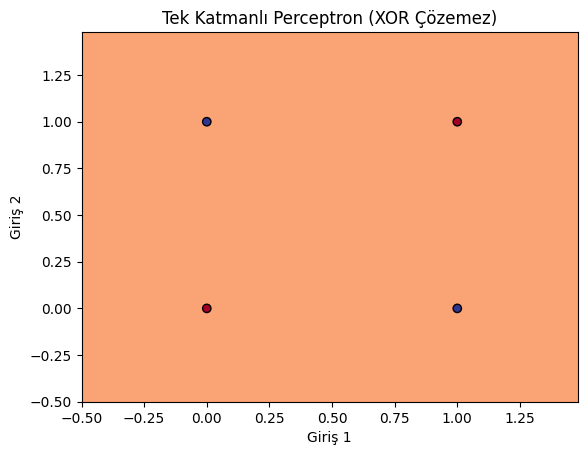

In [4]:
linear_model = Perceptron(max_iter=1000, random_state=42)
linear_model.fit(X, y)

print(f"Tek Katmanlı Başarı Skoru: {linear_model.score(X, y)}")
plot_decision_boundary(linear_model, X, y, "Tek Katmanlı Perceptron (XOR Çözemez)")

# Çok Katmanlı Sinir Ağı (Başarı)
Bu sefer model 1 olan noktaları 0 olanlardan ayırmak için karmaşık bir sınır çizer

Çok Katmanlı Başarı Skoru: 1.0


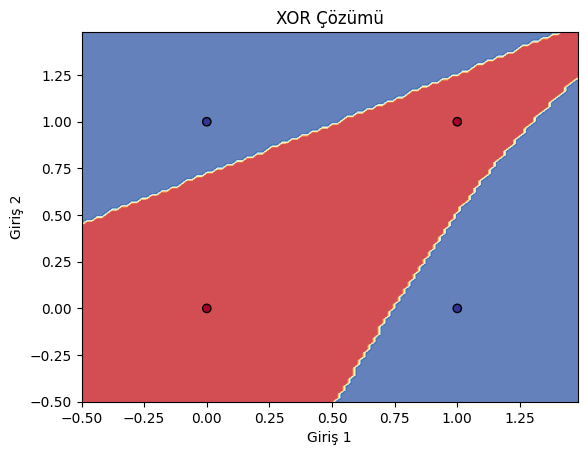

In [8]:
mlp_model = MLPClassifier(hidden_layer_sizes=(4, 2),
                            activation='tanh',
                            solver='lbfgs', 
                            max_iter=2000, 
                            random_state=1)

mlp_model.fit(X, y)

print(f"Çok Katmanlı Başarı Skoru: {mlp_model.score(X, y)}")
plot_decision_boundary(mlp_model, X, y, "XOR Çözümü")